In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
defensive_duels = pd.read_parquet("data/defensive_duels_valued.parquet")
matches = pd.read_parquet("data/matches.parquet")
leagues = pd.read_parquet("data/leagues.parquet")

In [4]:
defensive_duels["goal_conceded"] = defensive_duels.outcome == -1

In [5]:
all_events = pd.read_parquet("data/all_events.parquet")

In [6]:
xg_for = all_events.groupby(["matchId", "team_id"])["shot_xg"].sum()
match_total = all_events.groupby("matchId")["shot_xg"].sum()
xg_against = match_total - xg_for  # broadcasts over the team_id level

In [7]:
defensive_duel_total_values = defensive_duels.groupby(["matchId","team_id"])[["goal_conceded","duel_value"]].sum()
defensive_duels_avg_conceded = defensive_duels.groupby(["matchId","team_id"])[["duel_value"]].mean()

In [8]:
duel_win_rates = defensive_duels.groupby(["matchId","team_id"])[["groundDuel_recoveredPossession","groundDuel_stoppedProgress"]].mean()
duel_win_counts = defensive_duels.groupby(["matchId","team_id"])[["groundDuel_recoveredPossession","groundDuel_stoppedProgress"]].sum()

In [9]:
team_match_stats = (
    defensive_duel_total_values
    .rename(columns={"duel_value": "duel_value_sum"})
    .join(defensive_duels_avg_conceded.rename(columns={"duel_value": "duel_value_mean"}))
    .join(duel_win_rates.add_suffix("_rate"))
    .join(duel_win_counts.add_suffix("_count"))
    .join(xg_against.rename("xg_against"))
)

In [10]:
team_match_stats

goal_conceded  duel_value_sum  duel_value_mean  \
matchId team_id                                                   
5219995 28072                2       -0.127225        -0.002194   
        28443                2       -0.173822        -0.002519   
5219996 28320                2       -0.137106        -0.003116   
        28437                0        0.069871         0.001426   
5219997 27017                3        0.124368         0.001352   
...                        ...             ...              ...   
5663809 27938                0       -0.042068        -0.000628   
5663810 28240                2        0.047864         0.000563   
        28355                1        0.279849         0.004305   
5663811 27938                3       -0.078304        -0.001073   
        28355                0        0.083137         0.001732   

                 groundDuel_recoveredPossession_rate  \
matchId team_id                                        
5219995 28072                               0.224138   
        28443                               0.275362   
5219996 28320                               0.136364   
        28437                               0.285714   
5219997 27017                               0.258065   
...                                              ...   
5663809 27938                               0.268657   
5663810 28240                               0.235294   
        28355                               0.215385   
5663811 27938                               0.178082   
        28355                               0.354167   

                 groundDuel_stoppedProgress_rate  \
matchId team_id                                    
5219995 28072                           0.396552   
        28443                           0.405797   
5219996 28320                           0.409091   
        28437                           0.265306   
5219997 27017                           0.408602   
...                                          ...   
5663809 27938                           0.343284   
5663810 28240                           0.470588   
        28355                           0.538462   
5663811 27938                           0.438356   
        28355                           0.354167   

                 groundDuel_recoveredPossession_count  \
matchId team_id                                         
5219995 28072                                      13   
        28443                                      19   
5219996 28320                                       6   
        28437                                      14   
5219997 27017                                      24   
...                                               ...   
5663809 27938                                      18   
5663810 28240                                      20   
        28355                                      14   
5663811 27938                                      13   
        28355                                      17   

                 groundDuel_stoppedProgress_count  xg_against  
matchId team_id                                                
5219995 28072                                  23    2.242680  
        28443                                  28    1.179476  
5219996 28320                                  18    1.006020  
        28437                                  13    1.255291  
5219997 27017                                  38    1.318130  
...                                           ...         ...  
5663809 27938                                  23    2.214407  
5663810 28240                                  40    1.107061  
        28355                                  35    1.648892  
5663811 27938                                  32    1.593373  
        28355                                  17    0.984961  

[14590 rows x 8 columns]

<Axes: xlabel='duel_value_mean', ylabel='goal_conceded'>

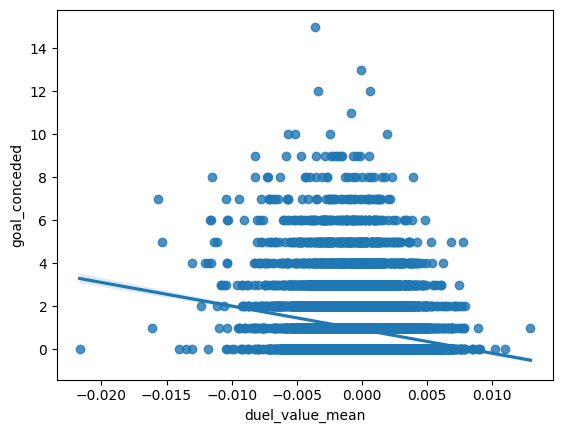

In [11]:
sns.regplot(data=team_match_stats.reset_index(), x="duel_value_mean", y="goal_conceded")

In [16]:
import statsmodels.api as sm
y = team_match_stats["goal_conceded"]
rows = []
for col in team_match_stats.columns.drop("goal_conceded"):
    x = sm.add_constant(team_match_stats[col])
    m = sm.OLS(y, x).fit()
    rows.append({
        "predictor": col,
        "slope": m.params[col],
        "std_err": m.bse[col],
        "t": m.tvalues[col],
        "p_value": m.pvalues[col],
        "r_squared": m.rsquared,
        "n": int(m.nobs),
    })
univariate_results = pd.DataFrame(rows).sort_values("r_squared", ascending=False).reset_index(drop=True)
univariate_results

,predictor,slope,std_err,t,p_value,r_squared,n
0,xg_against,0.557372,0.011388,48.944421,0.000000e+00,0.141052,14590
1,duel_value_sum,-2.061264,0.078613,-26.220486,4.093766e-148,0.045008,14590
2,duel_value_mean,-109.813930,4.387328,-25.029795,2.048101e-135,0.041177,14590
3,groundDuel_stoppedProgress_count,0.028785,0.001336,21.546089,2.178047e-101,0.030842,14590
4,groundDuel_recoveredPossession_rate,-2.846685,0.173206,-16.435272,3.711667e-60,0.018180,14590
5,groundDuel_recoveredPossession_count,0.020957,0.002394,8.752805,2.306549e-18,0.005224,14590
6,groundDuel_stoppedProgress_rate,0.036262,0.149478,0.242593,8.083242e-01,0.000004,14590


In [17]:
reg_games = pd.merge(leagues[~leagues.wyId.isin([43226,43049])][["wyId"]],matches[["wyId","competitionId","teams","winner","seasonId"]],left_on="wyId",right_on="competitionId")

In [18]:
import ast

m = reg_games[["seasonId", "teams", "winner"]].copy()
m["teams"] = m["teams"].apply(ast.literal_eval)
m = m.explode("teams")
m["team_id"] = m["teams"].astype(int)
m["win"] = m["team_id"] == m["winner"]
m["draw"] = m["winner"] == 0

season_win_rates = m.groupby(["seasonId", "team_id"]).agg(
    played=("win", "size"),
    wins=("win", "sum"),
    draws=("draw", "sum"),
)

season_win_rates["win_rate"] = season_win_rates["wins"] / season_win_rates["played"]
season_win_rates

played  wins  draws  win_rate
seasonId team_id                               
188201   24424        11     8      2  0.727273
         24426         9     3      2  0.333333
         24487        11     5      1  0.454545
         24488         9     3      1  0.333333
         24494        10     5      3  0.500000
...                  ...   ...    ...       ...
191037   24697         9     7      2  0.777778
         24698         9     3      1  0.333333
         24699         9     3      1  0.333333
         24701         8     3      2  0.375000
         28450         6     2      0  0.333333

[841 rows x 4 columns]

In [19]:
reg_match_ids = matches.loc[~matches.competitionId.isin([43226, 43049]), "wyId"]
season_by_match = matches.set_index("wyId")["seasonId"]

tms_reg = team_match_stats.loc[
    team_match_stats.index.get_level_values("matchId").isin(reg_match_ids)
].copy()
tms_reg["seasonId"] = tms_reg.index.get_level_values("matchId").map(season_by_match)

season_win_rates["duel_value_sum"] = (
    tms_reg.groupby(["seasonId", "team_id"])["duel_value_sum"].sum()
)
season_win_rates = season_win_rates[season_win_rates.played>6]

<Axes: xlabel='duel_value_sum', ylabel='win_rate'>

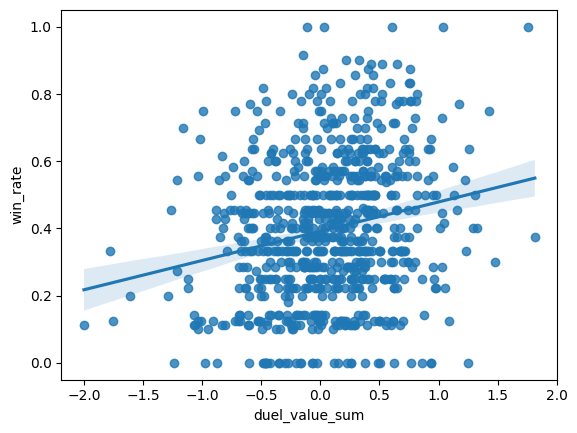

In [20]:
sns.regplot(data=season_win_rates.reset_index(), x="duel_value_sum", y="win_rate")

In [21]:
defensive_duels

,id,matchId,matchPeriod,matchTimestamp,time,start_x,start_y,team_id,opponentTeam_id,opponentTeam_name,...,sec_carry,sec_counterpressing_recovery,sec_dribbled_past_attempt,sec_foul_suffered,sec_progressive_run,sec_sliding_tackle,duel_outcome,duel_outcome_code,duel_value,goal_conceded
1,2065092753,5219995,1E,01:31:04.524,5464.524,9.6,10.4,28443,28072,American Eagles,...,True,False,True,False,False,False,recovered,1,0.012194,False
3,2065092760,5219995,1E,01:31:11.467,5471.467,52.8,13.6,28443,28072,American Eagles,...,False,False,False,False,False,False,stopped,2,0.000875,False
5,2065093237,5219995,1E,01:31:46.430,5506.430,22.8,52.0,28072,28443,Jacksonville Dolphins,...,False,False,False,False,False,False,beat,0,-0.044520,False
8,2065092790,5219995,1E,01:32:26.897,5546.897,32.4,74.4,28443,28072,American Eagles,...,False,False,False,False,False,False,beat,0,-0.005020,False
9,2065093246,5219995,1E,01:33:23.049,5603.049,55.2,8.8,28072,28443,Jacksonville Dolphins,...,False,False,False,False,False,False,stopped,2,0.001137,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1954733,2398482585,5663811,2H,01:40:34.199,6034.199,14.4,22.4,27938,28355,Vermont Catamouts,...,False,False,True,False,False,False,beat,0,-0.022552,False
1954736,2398482601,5663811,2H,01:42:30.202,6150.202,52.8,26.4,28355,27938,Marshall Thundering Herd,...,False,False,False,False,False,False,stopped,2,-0.001068,False
1954737,2398482634,5663811,2H,01:43:29.552,6209.552,15.6,10.4,28355,27938,Marshall Thundering Herd,...,False,False,False,False,False,False,stopped,2,0.004561,False
1954738,2398482633,5663811,2H,01:44:07.402,6247.402,34.8,22.4,27938,28355,Vermont Catamouts,...,False,False,True,False,False,False,beat,0,-0.011965,False


In [23]:
leagues

,wyId,name,format,type,category,gender,divisionLevel,id,alpha2code,alpha3code,name.1
0,43559,NCAA D1 Ohio Valley,Domestic league,club,default,male,1,840,US,USA,United States
1,43226,NCAA D1 Non-conference matches,Domestic league,club,default,male,1,840,US,USA,United States
2,43225,NCAA D1 Western Athletic,Domestic league,club,default,male,1,840,US,USA,United States
3,43224,NCAA D1 West Coast,Domestic league,club,default,male,1,840,US,USA,United States
4,43223,NCAA D1 Sun Belt,Domestic league,club,default,male,1,840,US,USA,United States
5,43222,NCAA D1 Summit League,Domestic league,club,default,male,1,840,US,USA,United States
6,43221,NCAA D1 Southern,Domestic league,club,default,male,1,840,US,USA,United States
7,43220,NCAA D1 Patriot League,Domestic league,club,default,male,1,840,US,USA,United States
8,43219,NCAA D1 Pacific 12,Domestic league,club,default,male,1,840,US,USA,United States
9,43218,NCAA D1 Northeast,Domestic league,club,default,male,1,840,US,USA,United States


In [36]:
bigWestMatches = matches[matches.competitionId == 43209][["wyId","seasonId"]]

In [46]:
bigWest_duel_values = pd.merge(bigWestMatches,defensive_duels[["matchId","player_name","duel_value","team_id"]],left_on="wyId",right_on="matchId",how="inner")

In [57]:
player_big_west_season_duel_values = bigWest_duel_values.groupby(["seasonId","player_name"]).agg({'team_id':'first','duel_value':"sum"}).reset_index()
player_big_west_season_duel_values_2025 = player_big_west_season_duel_values[player_big_west_season_duel_values.seasonId == 190927].sort_values(by="duel_value",ascending=False)

<Axes: >

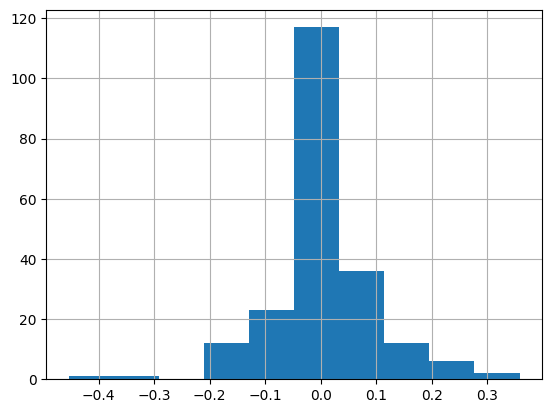

In [61]:
player_big_west_season_duel_values_2025["duel_value"].hist()

# UCSD has team id of 68155

In [56]:
team_big_west_season_duel_values = bigWest_duel_values.groupby(["seasonId","team_id"])[["duel_value"]].sum().reset_index()
team_big_west_season_duel_values[team_big_west_season_duel_values.seasonId==190927].sort_values(by="duel_value",ascending=False)

,seasonId,team_id,duel_value
30,190927,24424,1.155726
33,190927,24488,0.486107
31,190927,24426,0.407910
34,190927,24494,0.390510
38,190927,28356,0.368412
36,190927,28229,-0.020225
35,190927,28101,-0.068645
37,190927,28242,-0.118779
39,190927,68155,-0.232510
32,190927,24487,-0.735445
